In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv(r"C:\Users\Hp\Desktop\ML Batch\Class 7\train_Loan_Pred - 1739709327697.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


* **It is the classification problem as we have to predict the whether the loan is given or not**

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [81]:
df.shape

(614, 13)

In [83]:
df.Dependents.unique()

array(['0', '1', '2', '3+', nan], dtype=object)

<Axes: xlabel='LoanAmount', ylabel='Density'>

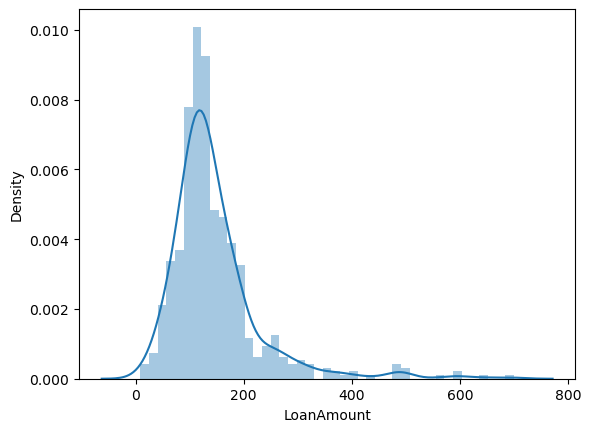

In [85]:
sns.distplot(df.LoanAmount)

In [86]:
# to check the unique values in the cols which will shows the cardinality

for i in df.columns:
    print(i ,'--------', df[i].nunique())

Loan_ID -------- 614
Gender -------- 2
Married -------- 2
Dependents -------- 4
Education -------- 2
Self_Employed -------- 2
ApplicantIncome -------- 505
CoapplicantIncome -------- 287
LoanAmount -------- 203
Loan_Amount_Term -------- 10
Credit_History -------- 2
Property_Area -------- 3
Loan_Status -------- 2


In [88]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [91]:
# to check the balancing of the dataset
df.Loan_Status.value_counts(normalize = True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

#### Null Values Handling

In [94]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [96]:
cat_col = ['Gender' , 'Married' , 'Dependents' , 'Self_Employed' , 'Loan_Amount_Term' ,'Credit_History']

for col in cat_col:
    print(col)
    val = df[col].mode().values[0]
    df[col] = df[col].fillna(val)

Gender
Married
Dependents
Self_Employed
Loan_Amount_Term
Credit_History


In [98]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [100]:
df.LoanAmount.fillna(df.LoanAmount.median() , inplace = True)

In [102]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

#### Outliers Treatment

In [105]:
conti_col = df.select_dtypes(include = 'number' )
conti_col.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

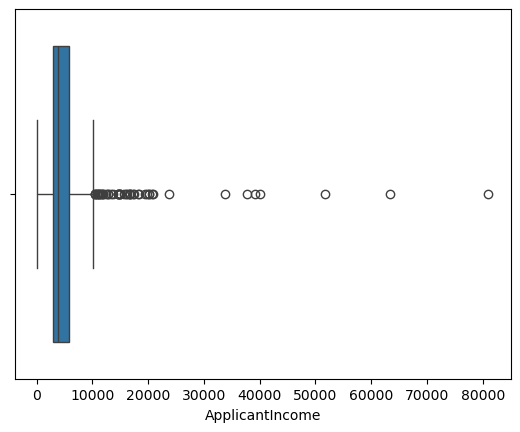

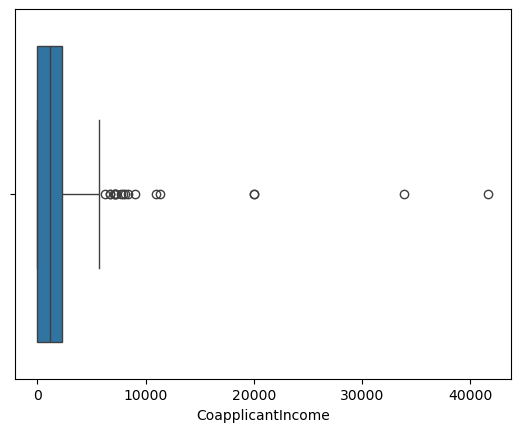

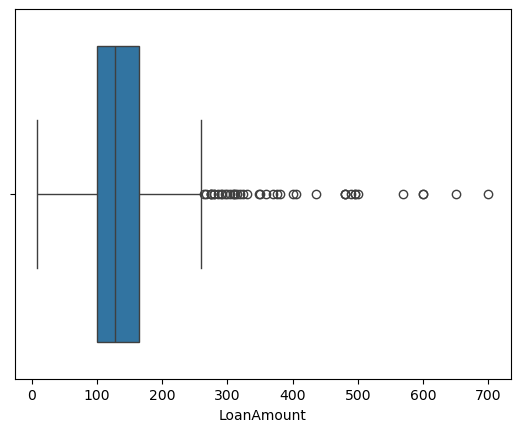

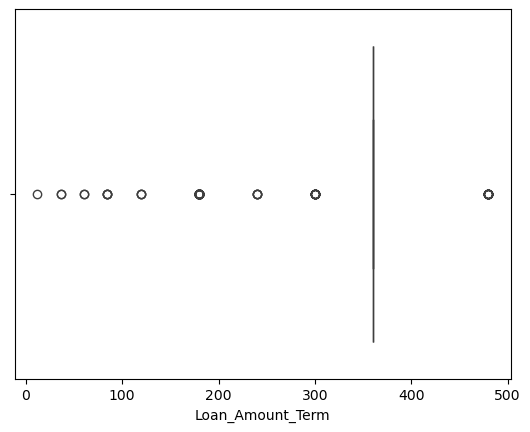

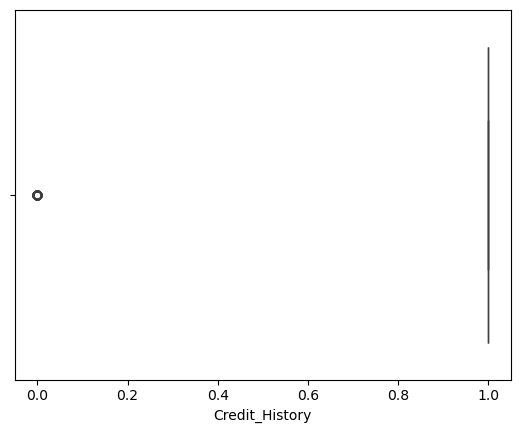

In [107]:
for i in conti_col.columns:
    sns.boxplot(data = df , x = i)
    plt.show()

In [108]:
# Outliers Treatment

for i in ['ApplicantIncome' , 'CoapplicantIncome', 'LoanAmount']:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    uc = q3+1.5*iqr
    lc = q1-1.5*iqr

    df[i] = df[i].clip( upper = uc , lower = lc )

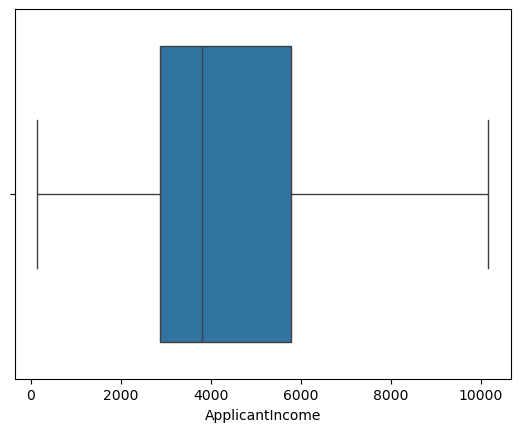

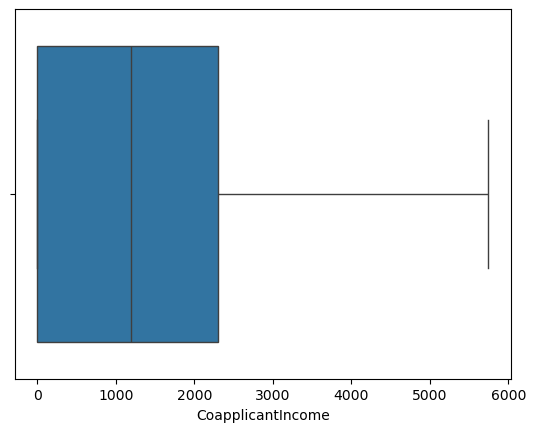

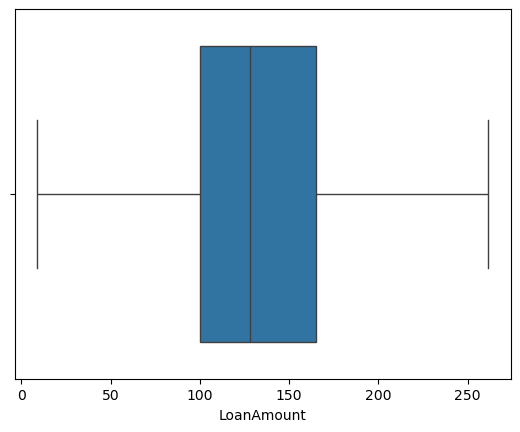

In [109]:
for i in ['ApplicantIncome' , 'CoapplicantIncome', 'LoanAmount']:
    sns.boxplot( data = df , x = i)
    plt.show()


#### Converting Categorigal to Numeric data

In [111]:
from sklearn.preprocessing import LabelEncoder

In [114]:
cat_cols = df.select_dtypes(exclude = 'number')
cat_cols.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [115]:
# saving the output of label encoding to be get used in the testing file

maping_dict = {}
for i in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']:
    le = LabelEncoder()
    df[i] = le.fit_transform(df[i])
    print(dict(zip(le.classes_,sorted(df[i].unique()))))
    temp_dt = dict(zip(le.classes_,sorted(df[i].unique())))
    maping_dict.update(temp_dt)

{'Female': 0, 'Male': 1}
{'No': 0, 'Yes': 1}
{'0': 0, '1': 1, '2': 2, '3+': 3}
{'Graduate': 0, 'Not Graduate': 1}
{'No': 0, 'Yes': 1}
{'Rural': 0, 'Semiurban': 1, 'Urban': 2}
{'N': 0, 'Y': 1}


In [116]:
maping_dict

{'Female': 0,
 'Male': 1,
 'No': 0,
 'Yes': 1,
 '0': 0,
 '1': 1,
 '2': 2,
 '3+': 3,
 'Graduate': 0,
 'Not Graduate': 1,
 'Rural': 0,
 'Semiurban': 1,
 'Urban': 2,
 'N': 0,
 'Y': 1}

In [117]:
temp_df = pd.DataFrame(maping_dict.items() , columns = ['Cols' , 'Values' ] )
temp_df.head(3)

,Cols,Values
0,Female,0
1,Male,1
2,No,0


In [120]:
#saving the results
temp_df.to_csv('mapping_dict_train.csv' , index = False )

In [126]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,2,1


In [128]:
# dropping the cols

df.drop(columns = 'Loan_ID' , axis = 1 , inplace = True)

In [130]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,2,1


<Axes: >

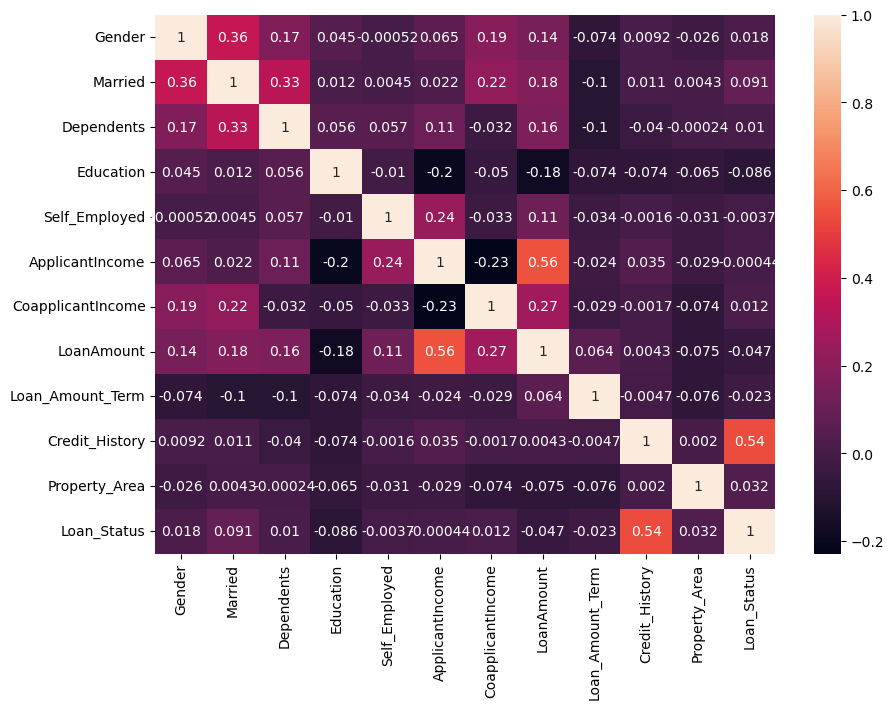

In [132]:
## Correlation Check
plt.figure(figsize = (10,7))
corr_matric = df.select_dtypes(include = 'number').corr()
sns.heatmap( corr_matric , annot = True )

#### Standardisation of the dataset

In [134]:
from sklearn.preprocessing import StandardScaler

In [135]:
X = df.iloc[:,:-1]
y = df.Loan_Status

In [139]:
ss = StandardScaler()
X_ft = ss.fit_transform(X)
X_ft = pd.DataFrame(X_ft)

In [141]:
X_ft.columns = X.columns

In [143]:
X_ft

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,0.497164,-0.874587,-0.168041,0.273231,0.411733,1.223298
1,0.472343,0.728816,0.253470,-0.528362,-0.392601,-0.013767,0.054395,-0.168041,0.273231,0.411733,-1.318513
2,0.472343,0.728816,-0.737806,-0.528362,2.547117,-0.652632,-0.874587,-1.280462,0.273231,0.411733,1.223298
3,0.472343,0.728816,-0.737806,1.892641,-0.392601,-0.820924,0.578025,-0.311579,0.273231,0.411733,1.223298
4,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,0.558104,-0.874587,0.065209,0.273231,0.411733,1.223298
...,...,...,...,...,...,...,...,...,...,...,...
609,-2.117107,-1.372089,-0.737806,-0.528362,-0.392601,-0.692990,-0.874587,-1.190750,0.273231,0.411733,-1.318513
610,0.472343,0.728816,2.236021,-0.528362,-0.392601,-0.206274,-0.874587,-1.746961,-2.522836,0.411733,-1.318513
611,0.472343,0.728816,0.253470,-0.528362,-0.392601,1.394319,-0.726739,2.074743,0.273231,0.411733,1.223298
612,0.472343,0.728816,1.244745,-0.528362,-0.392601,1.196969,-0.874587,0.890553,0.273231,0.411733,1.223298


In [145]:
import pickle

In [147]:
# we have to saved the results of standarization so that same scale would be given to the test dataset

with open('./standard_scaler.pkl' , 'wb' ) as file:
    pickle.dump(ss,file)


#### Splitting the Dataset into Train and Test

In [150]:
from sklearn.model_selection import train_test_split

In [152]:
xtrain,xtest,ytrain,ytest = train_test_split(X_ft, y , test_size = 0.20 , random_state = 44 , stratify = y)

In [154]:
xtrain.shape,xtest.shape,ytrain.shape,ytest.shape

((491, 11), (123, 11), (491,), (123,))

In [156]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [158]:
lr = LogisticRegression(penalty = 'l2' , solver = 'lbfgs')
lr.fit(xtrain,ytrain)

LogisticRegression()

In [160]:
pred = lr.predict(xtest)

In [162]:
pred

array([1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1])

In [164]:
from sklearn.metrics import accuracy_score , classification_report

In [166]:
accuracy_score(ytest,pred)

0.8130081300813008

In [168]:
print(classification_report(ytest,pred))

              precision    recall  f1-score   support

           0       0.94      0.42      0.58        38
           1       0.79      0.99      0.88        85

    accuracy                           0.81       123
   macro avg       0.87      0.70      0.73       123
weighted avg       0.84      0.81      0.79       123



In [170]:
lr_params = {'penalty' : ['l2'] , 'solver' : ['lbfgs' , 'newton-cg' , 'sag'] }
lr_params

{'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg', 'sag']}

In [172]:
lr1 = LogisticRegression()

In [215]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [217]:
random_search_lr = RandomizedSearchCV(lr1,lr_params)
random_search_lr.fit(xtrain,ytrain)
random_search_lr.best_params_

{'solver': 'lbfgs', 'penalty': 'l2'}

In [219]:
from sklearn.tree import DecisionTreeClassifier

In [221]:
dt = DecisionTreeClassifier(max_depth=2 , min_samples_split = 20)
dt.fit(xtrain,ytrain)

DecisionTreeClassifier(max_depth=2, min_samples_split=20)

In [180]:
pred_dt = dt.predict(xtest)

In [182]:
pred_dt

array([1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1])

In [184]:
accuracy_score(ytest,pred_dt)

0.7967479674796748

In [186]:
from sklearn.tree import plot_tree

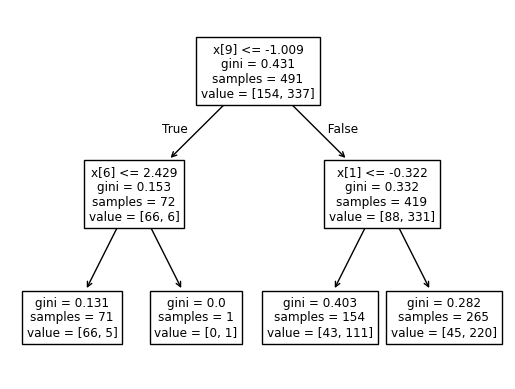

In [188]:
plot_tree(dt)
plt.show()

In [189]:
from sklearn.model_selection import RandomizedSearchCV , GridSearchCV

In [192]:
dt1 = DecisionTreeClassifier()

In [194]:
params_dt = {'max_depth' : [2,3,4,5] ,'min_samples_split' : [20,30,40,50 ] }

In [196]:
random_search = RandomizedSearchCV(dt1, params_dt)
random_search.fit(xtrain,ytrain)
random_search.best_params_

{'min_samples_split': 40, 'max_depth': 2}

In [197]:
grid_search = GridSearchCV(dt1 , params_dt)
grid_search.fit(xtrain,ytrain)
grid_search.best_params_

{'max_depth': 2, 'min_samples_split': 20}

In [198]:
from sklearn.ensemble import RandomForestClassifier

In [200]:
rfc = RandomForestClassifier()
rfc.fit(xtrain,ytrain)

RandomForestClassifier()

In [201]:
pred_rfc = rfc.predict(xtest)

In [202]:
accuracy_score(ytest,pred_rfc)

0.7886178861788617

* **Hence, Logistic Regression gives us the better accuracy. So we will be going ahead with that model**

In [206]:
# so we have to save the best model

with open ('./best_model.pkl' , 'wb' ) as file:
    pickle.dump(lr,file)